# Hourly IAM capacity experiment

This notebook applies the capacity model to a more realistic IAM-style workload.

The system has one shared capacity pool. Stochastic user demand is protected first. Prescheduled jobs then use the remaining capacity. Each scheduled job has a workload, a release hour, and a deadline.

The experiment still optimizes total capacity. The scheduled-job dispatch rule is fixed to earliest deadline first; job-order optimization is intentionally reserved for the next model layer.

## Project environment

The next cell keeps the notebook isolated from the global Python installation. It checks the project-local .venv, installs missing notebook dependencies there, and registers the Python (capacity-model) kernel.

If this notebook was opened with another kernel, run the cell once, select Python (capacity-model), and then rerun the notebook from the beginning.

In [1]:
from pathlib import Path
import subprocess
import sys

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

venv_dir = project_dir / ".venv"
venv_python = venv_dir / "bin" / "python"
requirements = project_dir / "requirements-notebook.txt"

if not venv_python.exists():
    subprocess.check_call([sys.executable, "-m", "venv", str(venv_dir)])

dependencies_ready = subprocess.run(
    [str(venv_python), "-c", "import ipykernel, jupyterlab, matplotlib"],
    capture_output=True,
).returncode == 0

if not dependencies_ready:
    subprocess.check_call(
        [str(venv_python), "-m", "pip", "install", "-r", str(requirements)]
    )

subprocess.check_call(
    [
        str(venv_python),
        "-m",
        "ipykernel",
        "install",
        "--sys-prefix",
        "--name",
        "capacity-model-venv",
        "--display-name",
        "Python (capacity-model)",
    ],
    stdout=subprocess.DEVNULL,
)

print(f"Project environment: {venv_dir}")
print(f"Current notebook interpreter: {sys.executable}")
if Path(sys.executable).resolve() == venv_python.resolve():
    print("Ready: this notebook is running inside Python (capacity-model).")
else:
    print("Setup complete. Select Python (capacity-model), then rerun from the beginning.")

Project environment: /Users/panos/.codex/.chatgpt-projects/g-p-6a63465261a081919fbf5287435162a5/capacity-model-starter/.venv
Current notebook interpreter: /Users/panos/.codex/.chatgpt-projects/g-p-6a63465261a081919fbf5287435162a5/capacity-model-starter/.venv/bin/python
Ready: this notebook is running inside Python (capacity-model).


## 1. Define the IAM experiment

The demand rate changes by hour: overnight demand is low, business-hour demand is higher, and a midday peak is highest. Scheduled jobs are known in advance but compete for residual capacity.

In [2]:
import sys
from pathlib import Path

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
sys.path.insert(0, str(project_dir / "src"))

from iam_capacity_model import (  # noqa: E402
    ScheduledJob,
    business_hour_lambda_profile,
    choose_iam_capacity,
    evaluate_iam_capacities,
    generate_hourly_poisson_scenarios,
    simulate_iam_scenario,
)

In [3]:
horizon = 24
scenario_count = 500
capacity_max = 24
seed = 20260830

capacity_cost = 1.0
user_backlog_cost = 10.0
scheduled_backlog_cost = 1.0
deadline_penalty = 25.0

lambda_profile = business_hour_lambda_profile(
    horizon,
    overnight_rate=2.0,
    business_rate=8.0,
    peak_rate=14.0,
)

scheduled_jobs = (
    ScheduledJob("nightly-reconcile", 0, 5, 12),
    ScheduledJob("directory-sync", 5, 10, 10),
    ScheduledJob("access-review", 8, 14, 14),
    ScheduledJob("policy-refresh", 12, 18, 16),
    ScheduledJob("report-export", 15, 23, 20),
)

print("Hourly demand profile:", lambda_profile)
print(f"Scheduled workload: {sum(job.workload for job in scheduled_jobs)} units")

Hourly demand profile: (2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 8.0, 8.0, 14.0, 14.0, 14.0, 14.0, 8.0, 8.0, 8.0, 8.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0)
Scheduled workload: 72 units


In [4]:
print("hour | expected user arrivals")
for hour, rate in enumerate(lambda_profile):
    print(f"{hour:4d} | {rate:22.1f}")

print("\njob               | release | deadline | workload")
for job in scheduled_jobs:
    print(
        f"{job.job_id:18s} | {job.release_period:7d} | "
        f"{job.deadline_period:8d} | {job.workload:8d}"
    )

hour | expected user arrivals
   0 |                    2.0
   1 |                    2.0
   2 |                    2.0
   3 |                    2.0
   4 |                    2.0
   5 |                    2.0
   6 |                    2.0
   7 |                    2.0
   8 |                    8.0
   9 |                    8.0
  10 |                   14.0
  11 |                   14.0
  12 |                   14.0
  13 |                   14.0
  14 |                    8.0
  15 |                    8.0
  16 |                    8.0
  17 |                    8.0
  18 |                    2.0
  19 |                    2.0
  20 |                    2.0
  21 |                    2.0
  22 |                    2.0
  23 |                    2.0

job               | release | deadline | workload
nightly-reconcile  |       0 |        5 |       12
directory-sync     |       5 |       10 |       10
access-review      |       8 |       14 |       14
policy-refresh     |      12 |       18 |     

## 2. Inspect one overload-containing future

Poisson demand creates many possible futures. We report the range of generated arrivals and inspect a path containing an arrival above the chosen inspection capacity.

In [5]:
demand_scenarios = generate_hourly_poisson_scenarios(
    lambda_profile,
    scenario_count,
    seed=seed,
)

inspection_capacity = 17
all_arrivals = [arrival for path in demand_scenarios for arrival in path]
overload_draws = sum(arrival > inspection_capacity for arrival in all_arrivals)
overload_scenarios = sum(
    any(arrival > inspection_capacity for arrival in path)
    for path in demand_scenarios
)
print(f"Maximum generated arrival: {max(all_arrivals)}")
print(f"Periods above capacity {inspection_capacity}: {overload_draws}")
print(f"Scenarios containing an overload: {overload_scenarios}/{len(demand_scenarios)}")

demand_path = next(
    (path for path in demand_scenarios if max(path) > inspection_capacity),
    demand_scenarios[0],
)
scenario = simulate_iam_scenario(
    inspection_capacity,
    demand_path,
    scheduled_jobs,
    capacity_cost_per_unit=capacity_cost,
    user_backlog_cost_per_unit=user_backlog_cost,
    scheduled_backlog_cost_per_unit=scheduled_backlog_cost,
    deadline_penalty_per_job=deadline_penalty,
)

print("\nhour | user arrivals | user served | scheduled released | scheduled served | user backlog | scheduled backlog | new misses")
for row in scenario.periods:
    print(
        f"{row.period:4d} | {row.user_arrivals:13d} | {row.user_served:11d} | "
        f"{row.scheduled_work_released:18d} | {row.scheduled_work_served:16d} | "
        f"{row.user_backlog_end:12d} | {row.scheduled_backlog_end:17d} | "
        f"{row.deadline_misses_new:10d}"
    )

Maximum generated arrival: 29
Periods above capacity 17: 355
Scenarios containing an overload: 277/500

hour | user arrivals | user served | scheduled released | scheduled served | user backlog | scheduled backlog | new misses
   0 |             0 |           0 |                 12 |               12 |            0 |                 0 |          0
   1 |             1 |           1 |                  0 |                0 |            0 |                 0 |          0
   2 |             0 |           0 |                  0 |                0 |            0 |                 0 |          0
   3 |             3 |           3 |                  0 |                0 |            0 |                 0 |          0
   4 |             4 |           4 |                  0 |                0 |            0 |                 0 |          0
   5 |             2 |           2 |                 10 |               10 |            0 |                 0 |          0
   6 |             2 |           2 

## 3. Compare total capacities

Each candidate capacity sees the same demand scenarios. We minimize total cost while reporting user service, scheduled-work completion, and deadline misses.

In [6]:
results = evaluate_iam_capacities(
    capacities=range(capacity_max + 1),
    demand_scenarios=demand_scenarios,
    scheduled_jobs=scheduled_jobs,
    capacity_cost_per_unit=capacity_cost,
    user_backlog_cost_per_unit=user_backlog_cost,
    scheduled_backlog_cost_per_unit=scheduled_backlog_cost,
    deadline_penalty_per_job=deadline_penalty,
)
selected = choose_iam_capacity(results)

print("capacity | expected cost | user fill | scheduled fill | avg deadline misses | avg scheduled backlog cost")
for result in results:
    print(
        f"{result.capacity:8d} | {result.total_cost:14.2f} | "
        f"{result.user_fill_rate:9.2%} | {result.scheduled_work_fill_rate:15.2%} | "
        f"{result.deadline_misses:19.2f} | {result.scheduled_backlog_cost:27.2f}"
    )

print(f"\nSelected capacity: {selected.capacity}")
print(f"Lowest estimated total cost: {selected.total_cost:.2f}")

capacity | expected cost | user fill | scheduled fill | avg deadline misses | avg scheduled backlog cost
       0 |       17053.18 |     0.00% |           0.00% |                5.00 |                     1074.00
       1 |       14132.96 |     1.82% |           0.37% |                5.00 |                     1067.80
       2 |       11570.85 |     4.26% |           3.41% |                5.00 |                     1021.81
       3 |        9730.84 |     6.94% |          12.01% |                4.95 |                      895.51
       4 |        8161.45 |    10.17% |          22.05% |                4.35 |                      747.81
       5 |        6715.30 |    14.46% |          28.45% |                3.58 |                      652.31
       6 |        5374.08 |    20.53% |          30.88% |                3.15 |                      614.34
       7 |        4126.47 |    28.99% |          34.72% |                3.02 |                      591.73
       8 |        3077.34 |    

## 4. Decision trade-off

Capacity reduces backlog and deadline risk, but every extra capacity unit costs money in every hour.

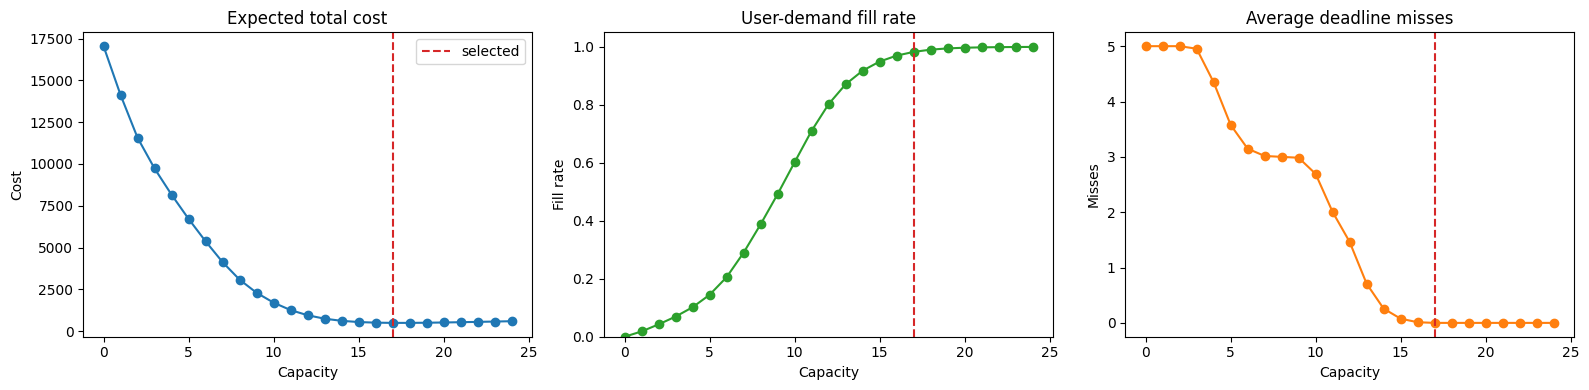

In [7]:
import matplotlib.pyplot as plt

capacities = [result.capacity for result in results]
costs = [result.total_cost for result in results]
user_fill = [result.user_fill_rate for result in results]
deadline_misses = [result.deadline_misses for result in results]

figure, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(capacities, costs, marker="o")
axes[0].axvline(selected.capacity, color="tab:red", linestyle="--", label="selected")
axes[0].set(title="Expected total cost", xlabel="Capacity", ylabel="Cost")
axes[0].legend()

axes[1].plot(capacities, user_fill, marker="o", color="tab:green")
axes[1].axvline(selected.capacity, color="tab:red", linestyle="--")
axes[1].set(title="User-demand fill rate", xlabel="Capacity", ylabel="Fill rate")
axes[1].set_ylim(0, 1.05)

axes[2].plot(capacities, deadline_misses, marker="o", color="tab:orange")
axes[2].axvline(selected.capacity, color="tab:red", linestyle="--")
axes[2].set(title="Average deadline misses", xlabel="Capacity", ylabel="Misses")

figure.tight_layout()
plt.show()

## Interpretation and publication boundary

This is a realistic synthetic IAM experiment, not a claim about a production IAM deployment. Its purpose is to establish a reproducible decision benchmark.

The model now captures the main operational asymmetry: user demand is uncertain and protected, while scheduled work is known in advance but may be delayed. The next research layer can optimize the scheduled-job allocation itself rather than using a fixed earliest-deadline-first rule.

For a public result, report the demand profile, job set, cost weights, random seed, scenario count, selected capacity, service metrics, and limitations together.